In [58]:
print("\n Task-1 :- Exploratory Data Analysis (EDA) on Retail Sales Data\n")


 Task-1 :- Exploratory Data Analysis (EDA) on Retail Sales Data



In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Data Loading and Cleaning:-

df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [36]:
print("Shape:", df.shape)

Shape: (1000, 9)


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [38]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [39]:
df = df.drop_duplicates()

In [40]:
df.ffill(inplace=True)

In [41]:
df['Date'] = pd.to_datetime(df['Date'])

In [42]:
print("\nCleaned Dataset :-")
df.head()


Cleaned Dataset :-


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [43]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [44]:
#Descriptive Statistics :-

print("\nMean Sales:", df['Total Amount'].mean())
print("\nMedian Sales:", df['Total Amount'].median())
print("\nMode Sales:", df['Total Amount'].mode()[0])
print("\nStandard Deviation: ", df['Total Amount'].std())


Mean Sales: 456.0

Median Sales: 135.0

Mode Sales: 50

Standard Deviation:  559.997631555123


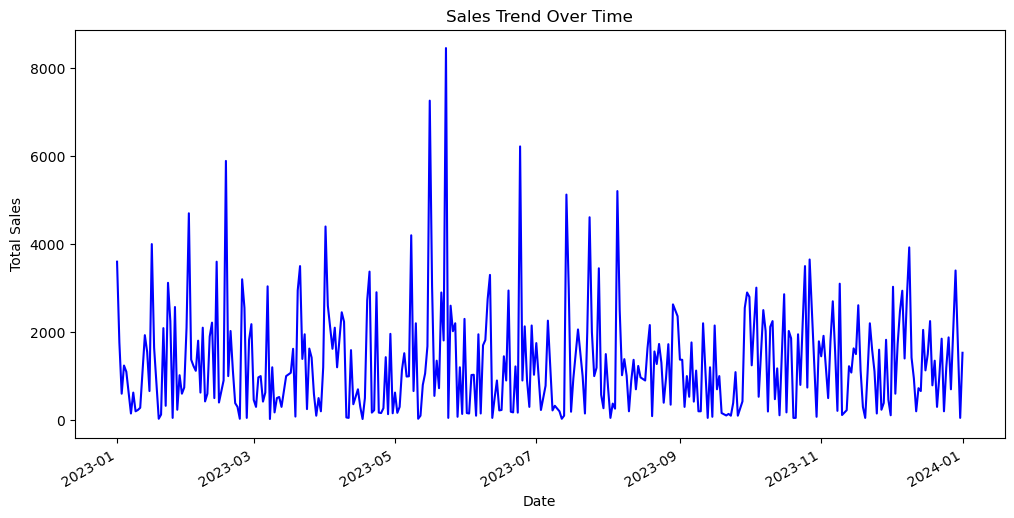

In [45]:
#Time Series Analysis :-
sales_trend = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(12,6))
sales_trend.plot(color='blue')

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

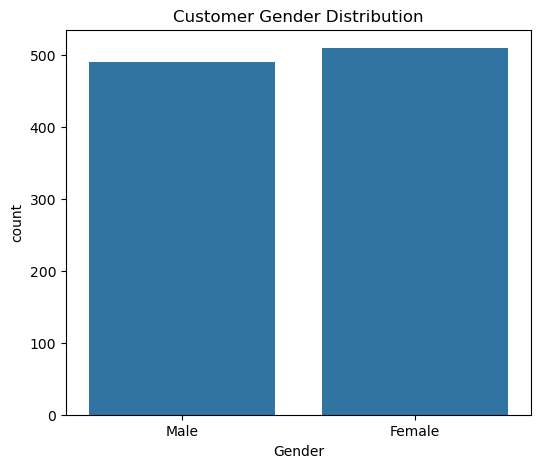

In [46]:
#Customer and Product Analysis :-

plt.figure(figsize=(6,5))

sns.countplot(x='Gender', data=df)

plt.title("Customer Gender Distribution")
plt.show()

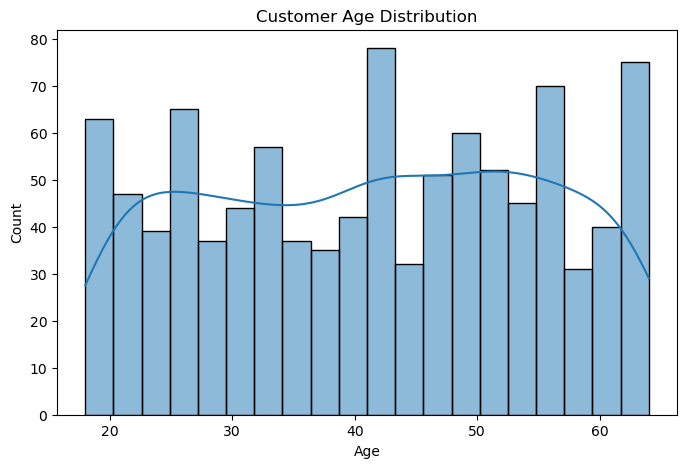

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.show()

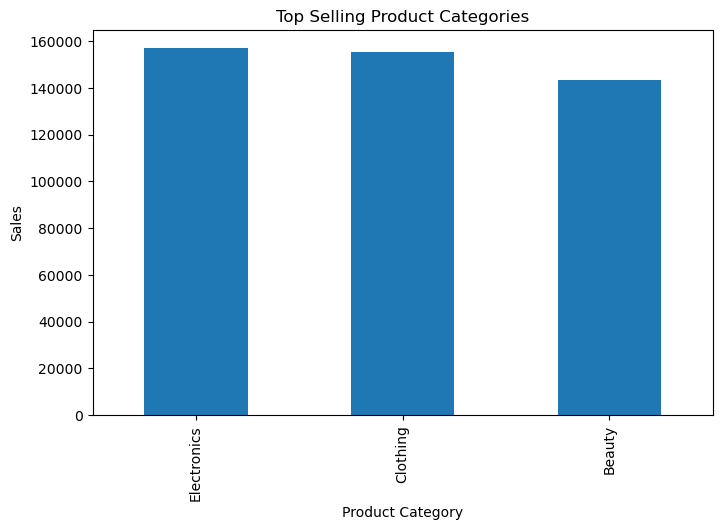

In [48]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

top_products.plot(kind='bar')

plt.title("Top Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.show()

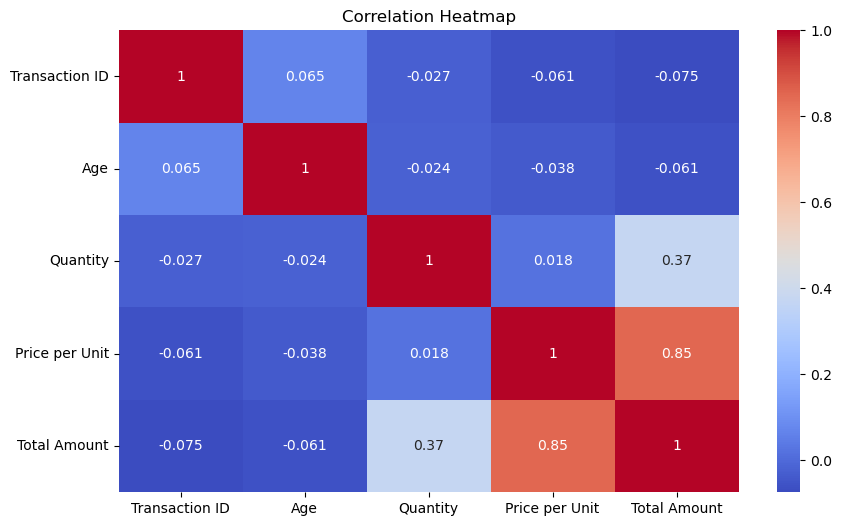

In [49]:
#Visualization :-
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

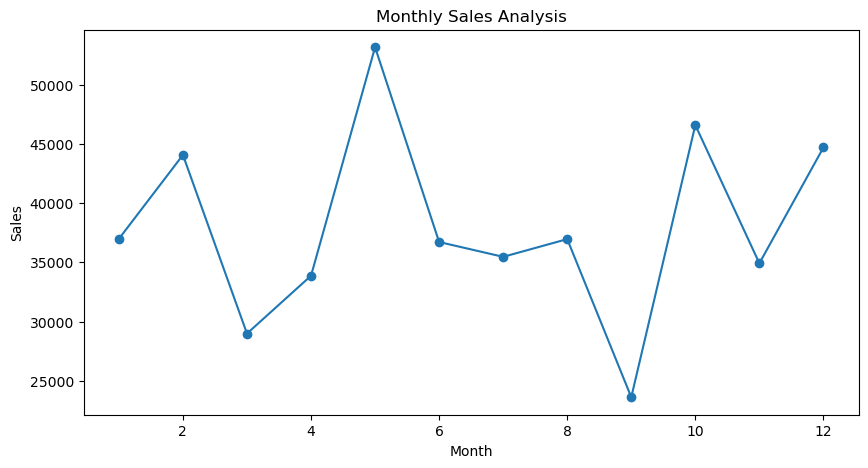

In [50]:
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()